# Análise do limite de similaridade

Este notebook faz uma análise que generaliza os resultados obtidos com os dados de teste no modelo LLM para todos os itens coletados do PNCP.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

#### Medicamentos do PNCP (não rotulados)

In [2]:
# Lê o arquivo de dados
med_pncp = pd.read_csv("../outputs/medicamentos-embeddings.csv")

# Seleciona as colunas que serão úteis
med_pncp = med_pncp[['endpoint', 'numeroItem', 'codigo_pdm', 'mais_similar', 'similaridade', 'nome_item']].rename(columns={"numeroItem": "numero_item"})

# Visualiza os dados
med_pncp.head(5)

,endpoint,numero_item,codigo_pdm,mais_similar,similaridade,nome_item
0,https://pncp.gov.br/api/pncp/v1/orgaos/0040255...,8.0,5116,267162,0.658831,"cloreto de potássio, dosagem:19,1%, apresentaç..."
1,https://pncp.gov.br/api/pncp/v1/orgaos/0040255...,9.0,1733,334381,0.581887,"acetato de cálcio, concentração:667 mg, caract..."
2,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,1.0,2259,445578,0.545600,"álcool etílico, teor alcoólico:absoluto, mínim..."
3,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,2.0,2259,445578,0.545600,"álcool etílico, teor alcoólico:absoluto, mínim..."
4,https://pncp.gov.br/api/pncp/v1/orgaos/0039454...,1.0,5804,461986,0.553030,"contraste radiológico, tipo:gasoso, composição..."


#### Medicamentos rotulados

In [3]:
# Lê o arquivo de dados
med_rotulados  = pd.read_csv("../inputs/medicamentos-rotulados.csv")

# Renomeia as colunas, padronizando-as
med_rotulados.columns = ['endpoint', 'numero_item', 'codigo_pdm', 'descricao', 'unidade_medida', 'rotulo', 'codigo_br', 'medicamento', 'observacao']

# Seleciona as colunas que serão úteis
med_rotulados = med_rotulados[['endpoint', 'numero_item', 'descricao', 'rotulo', 'codigo_br', 'medicamento']]

# Define os valores da rotulagem "Sim", "Não" e "Incerto"
med_rotulados["medicamento"] = med_rotulados["medicamento"].map({"Sim": "Sim", "Não": "Não"}).fillna("Incerto")

# Junta o resultado do modelo com os itens rotulados
med_rotulados = med_rotulados.merge(med_pncp, on = ['endpoint', 'numero_item'], how = 'inner')

# Visualiza os dados
med_rotulados.tail(5)

,endpoint,numero_item,descricao,rotulo,codigo_br,medicamento,codigo_pdm,mais_similar,similaridade,nome_item
995,https://pncp.gov.br/api/pncp/v1/orgaos/0350741...,12545,DUPILUMABE 150MG/ML SOLUÇÃO INJETÁVEL EM SERIN...,"PDM: 19654 - Dupilumabe, Concentração:150 MG/M...",455337.0,Sim,19654,455337,0.802756,"dupilumabe, concentração:150 mg/ml, forma farm..."
996,https://pncp.gov.br/api/pncp/v1/orgaos/0350741...,15609,"CABOZANTINIBE, LEVOMALATO 60 MG, COMPRIMIDO.","PDM: 19799 - Cabozantinibe, Composição:Levomal...",464682.0,Sim,19799,464682,0.693002,"cabozantinibe, composição:levomalato, concentr..."
997,https://pncp.gov.br/api/pncp/v1/orgaos/0039445...,1,Vitamina B12,NaN,NaN,Incerto,19967,604709,0.521868,"vitamina b12, concentração:5 mg/ml, forma farm..."
998,https://pncp.gov.br/api/pncp/v1/orgaos/1824174...,7,PROTEÍNA C REATIVA - MÉTODO IMUNOTURBIDIMÉTRIC...,"PDM: 30049 - Proteína C, Composição:Humana, Co...",600691.0,Sim,30049,600691,0.511556,"proteína c, composição:humana, concentração:10..."
999,https://pncp.gov.br/api/pncp/v1/orgaos/0351710...,370763,Tezepelumabe - Dosagem: 210 mg; Apresentação: ...,NaN,NaN,Incerto,30101,606824,0.725091,"tezepelumabe, concentração:110 mg/ml, forma fa..."


#### A partir de qual threshold paramos de ter falsos positivos nos dados de teste?

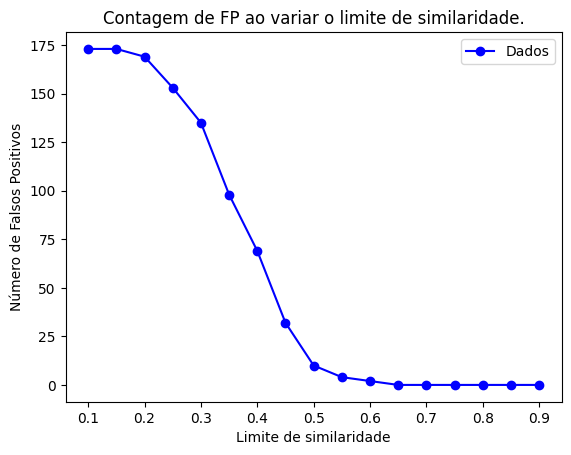

In [8]:
# Dados de teste vêm dos dados rotulados
teste_df = med_rotulados.copy()

# Converte "Sim" para True e "Não" para False na coluna "medicamento"
teste_df["medicamento"] = teste_df["medicamento"].map({"Sim": True, "Não": False})

# Remove os rotulos incertos (medicamento == nan)
teste_df = teste_df.dropna(subset=["medicamento"])

# Converte a coluna para booleano
teste_df['medicamento'] = teste_df['medicamento'].astype(bool)

resultados_fp = {}  # Falsos positivos

for limite in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    teste_df['medicamento_pred'] = teste_df['similaridade'] >= limite
    fp_count = len(teste_df[(teste_df['medicamento_pred']) & (~teste_df['medicamento'])])
    resultados_fp[limite] = fp_count

# Visualiza os resultados
# Extrai chaves e valores
eixo_x = list(resultados_fp.keys())
eixo_y = list(resultados_fp.values())

# Criar o gráfico de linha
plt.plot(eixo_x, eixo_y, marker='o', linestyle='-', color='b', label='Dados')

# Adiciona rótulos e título
plt.title("Contagem de FP ao variar o limite de similaridade.")
plt.xlabel("Limite de similaridade")
plt.ylabel("Número de Falsos Positivos")
plt.legend()

# Mostra o gráfico
plt.show()

In [9]:
# identifica o limite com a menor número de FP
limite = min(resultados_fp, key=resultados_fp.get)
print(f'O limite onde o número de FP chega a 0 é {limite}.')
print('Veja o número de FP para todos os limites abaixo:')
print(resultados_fp)

O limite onde o número de FP chega a 0 é 0.65.
Veja o número de FP para todos os limites abaixo:
{0.1: 173, 0.15: 173, 0.2: 169, 0.25: 153, 0.3: 135, 0.35: 98, 0.4: 69, 0.45: 32, 0.5: 10, 0.55: 4, 0.6: 2, 0.65: 0, 0.7: 0, 0.75: 0, 0.8: 0, 0.85: 0, 0.9: 0}


#### Distribuição da similaridade para todos os itens do PNCP

In [10]:
fig = px.histogram(med_pncp, x="similaridade")

# Adiciona títulos e legendas
fig.update_layout(
    title="Distribuição das similaridades nos itens do PNCP",
    xaxis_title="similaridade máxima",
    yaxis_title="Contagem"
)

fig.show()

#### Qual a proporção de itens do PNCP cuja similaridade está acima de 0.65?


In [11]:
proporcao = len(med_pncp[med_pncp['similaridade'] >= 0.65]) / len(med_pncp)
print(f'{round(proporcao*100,2)}% dos 145 mil itens coletados possuem similaridade de no mínimo {limite}')

proporcao = len(med_rotulados[med_rotulados['similaridade'] >= 0.65]) / len(med_rotulados)
print(f'{round(proporcao*100,2)}% dos 1000 itens rotulados manualmente possuem similaridade de no mínimo {limite}')

proporcao = len(med_pncp[med_pncp['similaridade'] >= 0.5]) / len(med_pncp)
print(f'{round(proporcao*100,2)}% dos 145 mil itens coletados possuem similaridade de no mínimo 0.5')

41.16% dos 145 mil itens coletados possuem similaridade de no mínimo 0.65
49.3% dos 1000 itens rotulados manualmente possuem similaridade de no mínimo 0.65
79.52% dos 145 mil itens coletados possuem similaridade de no mínimo 0.5


#### Como a similaridade está distribuída através dos rótulos?

In [12]:
# Criando o histograma
fig = px.histogram(
    med_rotulados,
    x="similaridade",         
    color="medicamento",    
    barmode="group",      
    title="Similaridade máxima por categorias rotuladas"
)

# Adiciona títulos e legendas
fig.update_layout(
    legend_title="Medicamento rotulado",
    xaxis_title="similaridade máxima",
    yaxis_title="Contagem"
)

# Exibir o gráfico
fig.show()

In [13]:
# mostrar mais texto ao visualizar dataframes
pd.set_option('display.max_colwidth', None)  

# Itens classificados como incertos e com similaridade acima de 0.7
med_rotulados[(med_rotulados['similaridade'] >= 0.7) & (med_rotulados['medicamento'] == "Incerto")][['similaridade', 'nome_item', 'descricao']]

,similaridade,nome_item,descricao
27,0.746909,"betametasona, composição:dipropionato, apresentação:associada com betametasona fosfato, dosagem:5mg + 2mg, uso:injetável","BETAMETASONA, DIPROPIONATO - CONCENTRACAO/DOSAGEM 4 MG/ML 1ML,FORMA FARMACEUTICA SOLUÇÃO INJETAVEL.,FORMA DE APRESENTACAO SOL INJ.,VIA DE ADMINISTRACAO INJETAVEL."
40,0.722608,"nistatina, dosagem:25.000 ui/g, apresentação:creme vaginal",NISTATINA CREME VAGINAL 50G+10APL C/50 UNIDADES
240,0.720732,"haloperidol, apresentação:sal decanoato, concentração:50 mg/ml, tipo uso:solução injetável","DECANOATO DE HALOPERIDOL 70,52MG/ML"
376,0.705063,"alprostadil, concentraçao:250 mcg, forma farmaceutica:pó liófilo p/injetável, característica adicional:formulação especialmente manipulada",ALPROSTADIL 20 mcg pó liofílico para solução injetável (frasco ampola). Item registrado na ata: 0025/2023
464,0.714663,"amoxicilina, concentração:25mg/ml, apresentação:pó para suspensão oral",AMOXICILINA 250MG/ML PÓ PARA SOLUÇÃO ORAL PÓ PARA SOLUÇÃO ORAL 150ML
467,0.769595,"amoxicilina, princípio ativo:associada com clavulanato de potássio, concentração:50 mg/ml + 12,5 mg/ml, forma farmacêutica:suspensão oral","AMOXICILINA + CLAVULANATO - CONCENTRACAO/DOSAGEM 400 MG + 57 MG RESPECTIVAMENTE, FORMA FARMACEUTICA SUSPENSAO ORAL, FORMA DE APRESENTACAO FRASCO, VIA DE ADMINISTRACAO ORAL."
526,0.707401,"ibuprofeno, dosagem:200 mg",IBUPROFENO DOSAGEM
548,0.715524,"sais para reidratação oral, composição:sódio, potássio, cloreto, citrato e glicose, concentração:45 mmol/l + 40 mmol/l + 70 mmol/l + 7 mmol/l + 125 mmol/l, forma farmacêutica:solução oral, características adicionais:formulação especialmente manipulada","SAIS DE REIDRATACAO ORAL CLORETO DE SODIO 3,5 G + GLICOSE 20 G + CITRATO DE SÓDIO 2,9 G + CLORETO DE POTÁSSIO 1,5 G, ENVELOPE. (CÓDIGO COMPRASNET: 446105)"
584,0.743830,"trometamol, composição:fosfomicina, concentração:3 g, forma farmacêutica:granulado","Fosfomicina trometamol - Dosagem: 5,631 gramas; Apresentação: granulado; Marca: Monuril."
615,0.709352,"álcool etílico, tipo:hidratado, teor alcoólico:70% ( 70°gl), apresentação:glicerinado, líquido","Alcool etilico, tipo: hidratado, 70%, composicao: glicerinado, gel antisseptico com glicerina 5 litrosAlcool etilico, tipo: hidratado, 70%, composicao: glicerinado, gel antisseptico com glicerina 5 litros"


In [14]:
# Restaura o comportamento padrão de visualização de dataframes
pd.reset_option('display.max_colwidth')

#### Qual a proporção de itens classificados como incertos dentre os que possuem similaridade acima de 0.65?

In [15]:
proporcao = (len(med_rotulados[(med_rotulados['similaridade'] >= 0.65) & (med_rotulados['medicamento'] == "Incerto")]) / 
 len((med_rotulados[med_rotulados['similaridade'] >= 0.65])))

print(f'{round(proporcao*100, 2)}% dos medicamentos com similaridade acima de 0.65 foram rotulados como incertos.')

5.68% dos medicamentos com similaridade acima de 0.65 foram rotulados como incertos.


#### Qual a proporção de "sim", "não" e "incerto" nos itens com similaridade >= 0.5?

In [16]:
med_rotulados[med_rotulados['similaridade'] >= 0.5].value_counts('medicamento', normalize=True)

medicamento
Sim        0.817602
Incerto    0.169643
Não        0.012755
dtype: float64

#### Conclusões

* Considerando como medicamentos somente os itens que obtiveram uma similaridade de pelo menos 0.65 com algum item do CATMAT, não temos nenhum falso positivo nos dados de teste.
* 41% dos 145 mil itens coletados apresentam uma similaridade de 0.65 ou superior com algum item do CATMAT.
* Dos 1000 itens rotulados manualmente, a proporção de itens com similaridade 0.65 ou superior é 49%. Dentre estes, cerca de 6% foram rotulados como incertos e em 94% dos casos foi possível identificar o código BR.
* Generalizando estes resultados para o total de 145 mil itens coletados, teríamos:
    * Cerca de 60 mil itens poderiam ser identificados como medicamentos. (41% de 145 mil)
    * Dentre estes, estima-se que cerca de 3400 possuiriam descrições ambíguas, e para os 56.600 itens restantes, seria possível identificar um código BR.


Se diminuirmos os limite de similaridade para considerar como medicamentos todos os itens que apresentarem similaridade de pelo menos 0.5 (resultado que apresentou maior acurácia da predição), temos nos dados de teste (1000 itens rotulados):
* 81,76% dos itens puderam ser identificados com o código BR;
* 1,28% dos itens são falsos positivos (não são realmente medicamentos);
* 16,96% dos itens estão ambíguos e não puderam ter o código BR identificado.

Generalizando estes resultados para os 145 mil itens coletados, teríamos:
* Cerca de 79,52% dos itens possuem similaridade de pelo menos 0.5, isto é, cerca de 115 mil itens.
* Destes 115 mil itens:
    * Cerca de 94 mil poderiam ter o código BR identificado;
    * Cerca de 1470 não seria medicamentos;
    * Cerca de 19.500 teriam uma descrição imprecisa, impossibilitando a sua identificação.


